In [ ]:
##
import geopandas as gpd # version 0.14.0
import pandas as pd # version 1.4.0
import numpy as np # version 1.22.2
import matplotlib.pyplot as plt # version 3.5.1
from shapely.geometry import Point # version 2.0.1
import hydrant.topology.geom as gm # version 0.1.0-dev1
import subprocess # built-in Python 3.10.2
##
import os # built-in Python 3.10.2  
import glob # built-in Python 3.10.2
import netCDF4 as nc
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors

# Base directories
base_scratch_dir = '/home/zelalem/github-repos'
#
input_basin_path = os.path.join(base_scratch_dir, 'community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp')
input_river_path = os.path.join(base_scratch_dir, 'community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_rivers.shp')
#
ddbnetcdf_path = os.path.join(base_scratch_dir, 'merit_mesh_outputs_landsat/MESH_drainage_database.nc')
parmnetcdf_path = os.path.join(base_scratch_dir, 'merit_mesh_outputs_landsat/SoilGrid_CanTransModel_MESH_parameters_withIWF.nc')

# Load the subbasins, rivers, and lakes shapefiles
boundary_path = os.path.join(base_scratch_dir, 'community-workflows/1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp')

## Read shapefiles of the required files
sub_agg_gdf = gpd.read_file(input_basin_path).to_crs(epsg=4326)
sub_agg_gdf['COMID'] = sub_agg_gdf['COMID'].astype(int)
#
riv_agg_gdf = gpd.read_file(input_river_path).to_crs(epsg=4326)
riv_agg_gdf['COMID'] = riv_agg_gdf['COMID'].astype(int)
#
boundary_gdf = gpd.read_file(boundary_path).to_crs(epsg=4326)

# Load NetCDF data using a context manager to handle file closing
with nc.Dataset(parmnetcdf_path) as dataset:
    # Extract variables directly into a DataFrame
    parameters_df = pd.DataFrame({
        'subbasin': dataset.variables['comid'][:].astype(int),
        'iwfflag': dataset.variables['iwf'][:].astype(int),
        'sdep': dataset.variables['sdep'][:]
    })
    # Extract land use classes and append as separate columns
    nsoil = [1,2,3,4]
    parameters_layer1 = dataset.variables['sand'][:]
    parameters_layer2 = dataset.variables['clay'][:]
    parameters_layer3 = dataset.variables['orgm'][:]
    
    for i, layer in enumerate(nsoil):
        parameters_df[f'sand{i+1}'] = parameters_layer1[:, i]
        parameters_df[f'clay{i+1}'] = parameters_layer2[:, i]
        parameters_df[f'orgm{i+1}'] = parameters_layer3[:, i]

## Merge aggreagted subbasin with drainage database
soil_merged_gdf = sub_agg_gdf.merge(parameters_df, left_on='COMID', right_on='subbasin', how='left')


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Select columns for plotting
soil_columns = soil_merged_gdf[['sand1','clay1','orgm1',
                                'sand2','clay2','orgm2', 
                                'sand3','clay3','orgm3',
                                'sand4','clay4','orgm4']]

# Create a modified jet colormap that sets zero values to white
cmap = plt.cm.gnuplot2_r.copy()
cmap.set_under('white', alpha=0)

# Set up the figure and axes for a 2x2 grid (4 plots)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10), sharex=True, sharey=True)

# Create an Image for colormap scaling
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=100))
sm._A = []  # Fake up the array of the scalar mappable

# Loop through and plot each column
for i, col in enumerate(soil_columns):
    ax = axes.flatten()[i]
    soil_merged_gdf.plot(column=col, ax=ax, cmap=cmap, vmin=0, vmax=100)
    boundary_gdf.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=0.2) # Plot boundaries
    ax.set_title(col, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide any unused subplots
for i in range(len(soil_columns), axes.flatten().shape[0]):
    axes.flatten()[i].set_visible(False)

# Adjust layout
fig.tight_layout(pad=1.0)
fig.subplots_adjust(right=0.85, hspace=0.02, wspace=0.1)

# Place colorbar
cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.ax.tick_params(labelsize=16) 

# Save the figure if needed
plt.savefig('soilgrid_soiltexture_plots_with_boundary.png')

# Show the plot
plt.show()

In [1]:
## Function to plot the parameters
import os # built-in Python 3.10.2
import geopandas as gpd
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator, FuncFormatter
##
def plot_soiltexture_distribution(
    input_basin_path: str,
    input_river_path: str,
    boundary_path: str,
    border_path: str,
    parmnetcdf_path: str,
    figsize=(10, 10),
    soil_layers=[1, 2, 3, 4],
    cmap_name="gnuplot2_r",
    output_png="soiltexture_distribution.png",
    dpi=300,
):

    print("Loading geospatial layers...")
    sub_gdf = gpd.read_file(input_basin_path).to_crs(epsg=4326)
    sub_gdf["COMID"] = sub_gdf["COMID"].astype(int)
    
    boundary_gdf = gpd.read_file(boundary_path).to_crs(epsg=4326)
    border_gdf = gpd.read_file(border_path).to_crs(epsg=4326)

    # Need area for percent
    if "unitarea" not in sub_gdf.columns:
        raise KeyError("unitarea column missing")
    sub_gdf["area_km2"] = sub_gdf["unitarea"]

    # ==== Read NetCDF (NO pandas used) ====
    print(f"Reading NetCDF: {parmnetcdf_path}")
    with nc.Dataset(parmnetcdf_path, "r") as ds:
        comid_nc = ds["comid"][:].astype(int)
        iwf = ds["iwf"][:]
        sdep = ds["sdep"][:]
        sand = ds["sand"][:]  # shape (N,4)
        clay = ds["clay"][:]
        orgm = ds["orgm"][:]

    # ==== Build soil data arrays ====
    soil_data = {}
    for i, lyr in enumerate(soil_layers):
        soil_data[f"sand{lyr}"] = sand[:, i]
        soil_data[f"clay{lyr}"] = clay[:, i]
        soil_data[f"orgm{lyr}"] = orgm[:, i]

    soil_columns = list(soil_data.keys())

    # ==== Merge manually (numpy-index match to COMID) ====
    print("Merging soil attributes into GeoDataFrame...")

    comid_to_index = {cid: i for i, cid in enumerate(comid_nc)}

    for col in soil_columns:
        col_values = np.zeros(len(sub_gdf))
        for i, comid in enumerate(sub_gdf["COMID"]):
            if comid in comid_to_index:
                col_values[i] = soil_data[col][comid_to_index[comid]]
            else:
                col_values[i] = 0.0
        sub_gdf[col] = col_values

    # ==== Area-weighted percentages ====
    total_area = sub_gdf["area_km2"].sum()
    mean_percent = []
    for col in soil_columns:
        mean_val = (sub_gdf[col] * sub_gdf["area_km2"]).sum() / total_area
        mean_percent.append(round(mean_val, 2))

    # ==== Plot setup ====
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_under("white")
    norm = mcolors.Normalize(vmin=0, vmax=100)

    # Latitude/longitude formatting
    deg_formatter = FuncFormatter(lambda x, pos: f"{int(x)}°")
    desired_lons = np.arange(-180, 181, 25)
    desired_lats = np.arange(-90, 91, 25)

    rows, cols = 4, 3
    fig, axes = plt.subplots(rows, cols, figsize=figsize, sharex=True, sharey=True)
    axes = axes.flatten()

    # ==== Plot ====
    for idx, (ax, col, perc) in enumerate(zip(axes, soil_columns, mean_percent)):

        # Plot field
        sub_gdf.plot(
            column=col,
            ax=ax,
            cmap=cmap,
            norm=norm,
            edgecolor="none"
        )

        boundary_gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.6)
        border_gdf.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=0.9)

        ax.set_title(col, fontsize=12)

        r, c = divmod(idx, cols)

        # Longitude ticks
        if r == rows - 1:
            ax.xaxis.set_major_locator(FixedLocator(desired_lons))
            ax.xaxis.set_major_formatter(deg_formatter)
            ax.tick_params(labelbottom=True)
        else:
            ax.tick_params(labelbottom=False)

        # Latitude ticks
        if c == 0:
            ax.yaxis.set_major_locator(FixedLocator(desired_lats))
            ax.yaxis.set_major_formatter(deg_formatter)
            ax.tick_params(labelleft=True)
        else:
            ax.tick_params(labelleft=False)

        # Axis labels
        if r == 1 and c == 0:
            ax.set_ylabel("Latitude", fontsize=14)
        if r == rows - 1 and c == 1:
            ax.set_xlabel("Longitude", fontsize=14)

        # Percentage text
        ax.text(
            0.04, 0.94, f"{perc:.2f}%",
            transform=ax.transAxes,
            fontsize=10, ha="left", va="top"
        )

    # ==== Colorbar ====
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        location="right",
        fraction=0.03,
        pad=0.02
    )
    cbar.set_label("soil texture content (%)", rotation=270, labelpad=20, fontsize=14)

    # ==== Title ====
    fig.suptitle(
        "Soil Texture Distribution (Sand / Clay / Organic Matter per Layer)",
        fontsize=14,
        y=0.92   # <-- push title closer to plots
    )

    if output_png:
        plt.savefig(output_png, dpi=dpi, bbox_inches="tight")
        print(f"Saved → {output_png}")

    plt.show()

Loading geospatial layers...
Reading NetCDF: /home/zelalem/github-repos/merit_mesh_outputs_landsat/SoilGrid_CanTransModel_MESH_parameters_withIWF.nc
Merging soil attributes into GeoDataFrame...
Saved → soilgrid_soil_texture_map.png


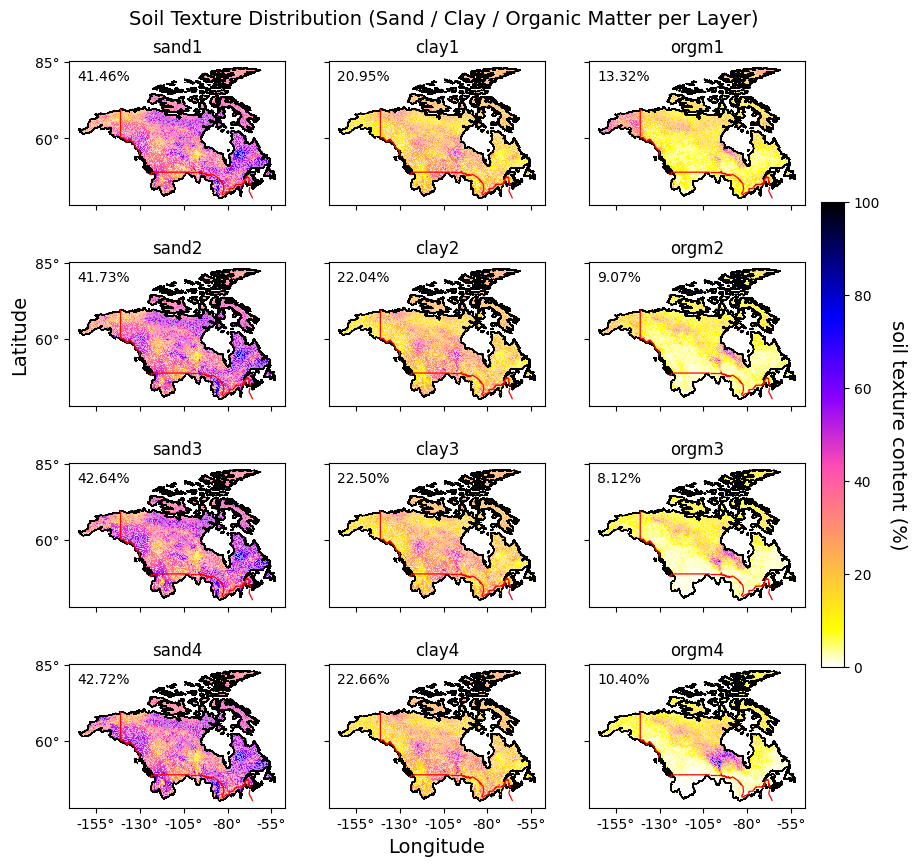

In [2]:
# Base directories
base_scratch_dir = '/home/zelalem/github-repos'
plot_soiltexture_distribution(
    input_basin_path=os.path.join(base_scratch_dir, "community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_subbasins.shp"),
    input_river_path=os.path.join(base_scratch_dir, "community-workflows/1-geofabric/MERIT/CanTrans-merit-geofabric/agg_MERIT_CanTrans_rivers.shp"),
    boundary_path=os.path.join(base_scratch_dir, "community-workflows/1-geofabric/study-domain/CanTrans_MERIT_StudyDomain.shp"),
    border_path=os.path.join(base_scratch_dir, "community-workflows/1-geofabric/study-domain/US-Canada_Boundary_v1_3.shp"),
    parmnetcdf_path=os.path.join(base_scratch_dir, "merit_mesh_outputs_landsat/SoilGrid_CanTransModel_MESH_parameters_withIWF.nc"),
    output_png="soilgrid_soiltexture_map.png"
)